In [26]:
# Import required libraries
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

from config.config import *
from src.models.model1 import BinaryClassificationModel
import src.utils as ut
from sklearn.metrics import accuracy_score, roc_auc_score
from src.databases import PersistenceDiagramDatabase
from persim import wasserstein, bottleneck, plot_diagrams, PersistenceImager

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [27]:
# Load train, test datasets
train_dataset = ut.SeismicDataset(data_path=Path("../data/processed/signals_train.hdf5"))
test_dataset = ut.SeismicDataset(data_path=Path("../data/processed/signals_test.hdf5"))

print(f"\n✓ Datasets loaded successfully")
print(f"  Train: {len(train_dataset)} signals")
print(f"  Test: {len(test_dataset)} signals")
print(f"\nSample (signal, label, magnitude): {train_dataset[0]}")


✓ Datasets loaded successfully
  Train: 260 signals
  Test: 69 signals

Sample (signal, label, magnitude): (array([7945794, 7945783, 7945780, ..., 7945061, 7945130, 7945650],
      shape=(6743,), dtype=int32), np.int64(1), np.float64(4.2))


Unitary test

In [28]:
from src.utils import compute_persistence, takens_embedding

signal0, label0, mag0 = train_dataset[0]
print(f"Signal shape: {signal0.shape}, Label: {label0}, Magnitude: {mag0}")
print(f"Signal stats ; Mean: {np.mean(signal0)}, Std: {np.std(signal0)}, Min: {np.min(signal0)}, Max: {np.max(signal0)}")

Signal shape: (6743,), Label: 1, Magnitude: 4.2
Signal stats ; Mean: 7945288.270947649, Std: 6339.873434466724, Min: 7866073, Max: 8029770


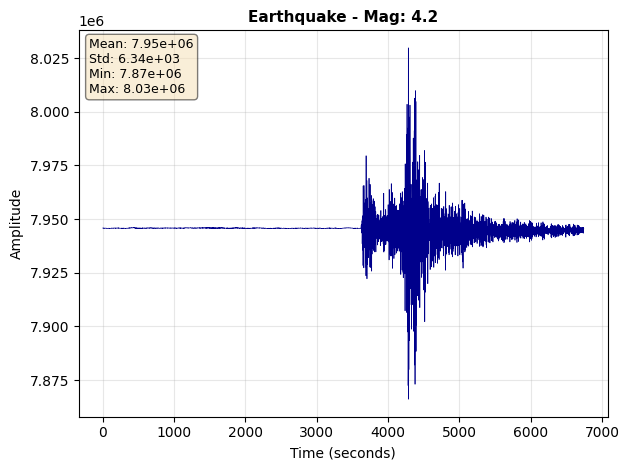

In [29]:
ut.plot_waveform(signal=signal0, label='Earthquake', mag=mag0)

In [30]:
takens_embedding0 = takens_embedding(signal0, dim=100, tau=10)
takens_embedding0.shape

(5753, 100)

In [31]:
takens_embedding0

array([[7945794., 7945742., 7945674., ..., 7945799., 7945752., 7945806.],
       [7945783., 7945719., 7945659., ..., 7945805., 7945791., 7945754.],
       [7945780., 7945751., 7945712., ..., 7945779., 7945824., 7945795.],
       ...,
       [7946741., 7946816., 7943092., ..., 7945580., 7945492., 7945061.],
       [7944289., 7948305., 7947445., ..., 7944701., 7943548., 7945130.],
       [7944869., 7943410., 7946434., ..., 7945010., 7943509., 7945650.]],
      shape=(5753, 100))

Manejar 5753 points es muy costoso computacionalmente. Hay que hacer un subsampling.

In [42]:
from gudhi.subsampling import choose_n_farthest_points as fps

# Compute takens_embedding0 if not already defined
signal0, label0, mag0 = train_dataset[0]
takens_embedding0 = takens_embedding(signal0, dim=100, tau=10)

# fps returns the actual points, already as numpy array
fps_points0 = np.array(fps(takens_embedding0, nb_points=500, starting_point=None))
print(f"Original embedding shape: {takens_embedding0.shape}")
print(f"Sampled points shape: {fps_points0.shape}")
print(f"Sample point: {fps_points0[0][:5]}...")  # First 5 values of first point

Original embedding shape: (5753, 100)
Sampled points shape: (500, 100)
Sample point: [7945675. 7945611. 7945642. 7945725. 7945753.]...


Idea: samplear pointclouds 5753 -> 500 points

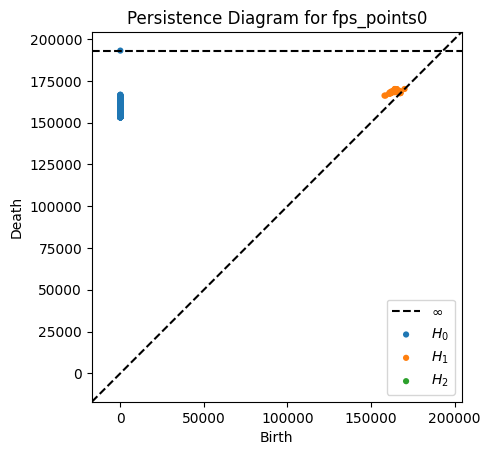

In [46]:
THRESH=1000
# Compute persistence diagram for fps_points0
diagram_fps = compute_persistence(fps_points0, maxdim=2)
plot_diagrams(diagram_fps, show=True, title='Persistence Diagram for fps_points0')

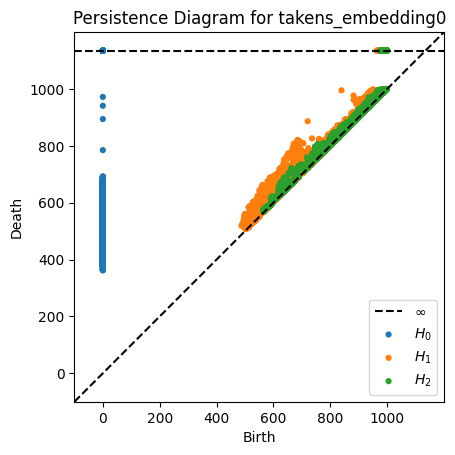

Wasserstein distance between H0 diagrams: 57011323.437648475


In [47]:
# Compute persistence diagram for takens_embedding0 (already done as diagram0)
diagram0 = compute_persistence(takens_embedding0, maxdim=2, thresh=THRESH)
plot_diagrams(diagram0, show=True, title='Persistence Diagram for takens_embedding0')

# Compare using Wasserstein distance
dist = wasserstein(diagram_fps[0], diagram0[0])  # For H0
print(f"Wasserstein distance between H0 diagrams: {dist}")